# Illegal zoning
_they made the character of our neighboorhoods illegal_

Waltham, like a [lot](https://cityobservatory.org/the-illegal-city-of-somerville/) of [other](https://www.nytimes.com/interactive/2016/05/18/upshot/which-buildings-in-manhattan-couldnt-be-built-again-today.html) cities with zoning codes, has a bit of a silly problem.
You see, the zoning is so restrictive in some places, that the existing structures could not be rebuilt.
Everything would have to go through a special permit, which is time consuming and expensive. You can imagine a lot of people
wouldn't even bother and just build where the zoning is easier.

What's the scale of the problem?

In this notebook, I'll load GIS shapefiles data (some from MassGIS, some from the city) try to determine where Waltham has this issue. Some of these violations can only be confirmed by surveying,
so I'll only tackle the simpler ones here.

In [1]:

import pandas as pd
import folium
from folium.plugins import Search
import os
import datetime
import geopandas as geo_pd
import seaborn as sns
from matplotlib import pyplot as plt

from investigations import StreetViewPanel

# data fetching
from data.connect_db import get_db

%matplotlib inline

# constants
from waltham.constants import SQ_FT_PER_ACRE, FT_PER_STORY

ACRE_TO_M2 = 4046.86
CURRENT_YEAR = datetime.datetime.now().year

con = get_db()


In [2]:
# some constants
PARCEL_SIZE_TOO_SMALL = "parcel_size_too_small"
STORIES_HIGH = "stories_high"
LOT_COVERAGE_HIGH = "lot_coverage_too_high"
FAR_HIGH = "far_high"
TOO_MANY_UNITS_PER_ACRE = "too_many_units_per_acre"
ANY_VIOLATIONS = "any_violations"

PARCEL_AREA_ACRE = "PARCEL_AREA_ACRE"
BLDG_FOOTPRINT_ACRE = "BLDG_FOOTPRINT_ACRE"

## Load shapefiles for buildings, zones, and parcels as well as the tax assessments data

In [3]:

query = """
select
    *
from
    "M308TaxPar_CY25_FY25"
"""

property_shapefiles_df = geo_pd.read_postgis(query, con)

# filter out right of way and water etc. property types
property_shapefiles_df = property_shapefiles_df[property_shapefiles_df["POLY_TYPE"] == "FEE"]
property_shapefiles_df = property_shapefiles_df[["LOC_ID", "geom", "SHAPE_AREA"]]
property_shapefiles_df.rename(columns={"SHAPE_AREA": PARCEL_AREA_ACRE}, inplace=True)

# MassGIS data is in m^2
property_shapefiles_df[PARCEL_AREA_ACRE] = property_shapefiles_df[PARCEL_AREA_ACRE] / ACRE_TO_M2

query = """
select
    *
from
    "M308Assess_CY25_FY25"
"""

assessments_df = pd.read_sql(query, con)
assessments_df = assessments_df[["LOC_ID", "SITE_ADDR", "YEAR_BUILT", "UNITS", "RES_AREA", "STORIES", "USE_CODE", "BLD_AREA"]]

### Data cleaning
See comments for reasoning

In [4]:
# use codes should be ints, since they're grouped by hundreds typically
assessments_df["USE_CODE"] = assessments_df["USE_CODE"].astype(int)

# and filter out anything that's not housing
# ref. https://www.mass.gov/doc/property-type-classification-codes-non-arms-length-codes-and-sales-report-spreadsheet/download
assessments_df = assessments_df[assessments_df["USE_CODE"] < 200]

# units should be ints; remove any NaNs and corece the rest to ints
assessments_df = assessments_df[~assessments_df["UNITS"].isna()]
assessments_df["UNITS"] = assessments_df["UNITS"].astype(int)


# when YEAR_BUILT is not present, assume current_year - 75 (per zoning code rules about historical review)
assessments_df["YEAR_BUILT"] = assessments_df["YEAR_BUILT"].fillna(CURRENT_YEAR - 75)
assessments_df["YEAR_BUILT"] = assessments_df["YEAR_BUILT"].astype(int)

# we care only about housing for this analysis - filter out other uses
# bin YEAR_BUILT to 5 year intervals since this data was less accurate in the past
#assessments_df["YEAR_BUILT"] = (assessments_df["YEAR_BUILT"] // 5).round().astype(int) * 5

# using 14 ft/story (TODO: find a reference for this value),
# and converting to meters for later QGIS use (CRS is in meters)
M_PER_FT = 0.3048
assessments_df["assumed_height"] = assessments_df["STORIES"].apply(lambda x: 0 if x is None else float(x)* FT_PER_STORY * M_PER_FT)

In [5]:
assessments_df

,LOC_ID,SITE_ADDR,YEAR_BUILT,UNITS,RES_AREA,STORIES,USE_CODE,BLD_AREA,assumed_height
0,F_736409_2970109,37 HUMBOLDT ST,1942,1,1488.0,1,101,2742.0,4.2672
1,F_725233_2956512,30 -32 RUMFORD AVE,1890,2,2280.0,2,104,3429.0,8.5344
2,F_733391_2963978,172 ROSE HILL WAY,1947,1,1260.0,1,101,2264.0,4.2672
3,F_736755_2970139,17 ROYAL ST,1952,1,1533.0,2,101,1902.0,8.5344
4,F_733356_2963776,175 ROSE HILL WAY,1945,1,1380.0,1,101,2396.0,4.2672
...,...,...,...,...,...,...,...,...,...
16591,F_725115_2956638,18 -20 RUMFORD AVE,1890,2,2247.0,2,104,3278.0,8.5344
16592,F_733265_2963813,167 ROSE HILL WAY,1955,1,1254.0,1,101,2482.0,4.2672
16593,F_725151_2956600,22 RUMFORD AVE,1890,2,2298.0,2,104,3521.0,8.5344
16594,F_733318_2963979,170 ROSE HILL WAY,1948,1,1080.0,2,101,2104.0,8.5344


In [6]:
property_shapefiles_df

,LOC_ID,geom,PARCEL_AREA_ACRE
0,F_720118_2954451,"MULTIPOLYGON (((219510.406 900516.563, 219505....",0.103024
1,F_720144_2954524,"MULTIPOLYGON (((219521.229 900544.743, 219512....",0.216257
2,F_722474_2954539,"MULTIPOLYGON (((220212.276 900527.633, 220199....",0.102640
3,F_720055_2954540,"MULTIPOLYGON (((219481.807 900560.359, 219483....",0.265953
4,F_720183_2954604,"MULTIPOLYGON (((219530.434 900568.77, 219524.3...",0.152051
...,...,...,...
13632,F_726818_2966119,"MULTIPOLYGON (((221510.552 904076.566, 221508....",0.228725
13633,F_726801_2966189,"MULTIPOLYGON (((221508.837 904085.225, 221505....",0.226193
13634,F_728791_2958677,"MULTIPOLYGON (((222155.564 901809.898, 222151....",0.140997
13635,F_731097_2960311,"MULTIPOLYGON (((222847.461 902289.338, 222821....",0.135689


In [7]:
query = """
select
    *
from
    "structures_poly_308"
"""
buildings_df = geo_pd.read_postgis(query, con)
buildings_df = buildings_df[["geom", "SHAPE_AREA"]]
buildings_df.rename(columns={"SHAPE_AREA": BLDG_FOOTPRINT_ACRE}, inplace=True)

# MassGIS data is in m^2
buildings_df[BLDG_FOOTPRINT_ACRE] = buildings_df[BLDG_FOOTPRINT_ACRE] / ACRE_TO_M2

buildings_df.head()

,geom,BLDG_FOOTPRINT_ACRE
0,"MULTIPOLYGON (((221761.404 902058.868, 221760....",0.051775
1,"MULTIPOLYGON (((220745.377 903053.674, 220730....",0.054356
2,"MULTIPOLYGON (((221283.985 901835.588, 221280....",0.031126
3,"MULTIPOLYGON (((221292.795 905675.213, 221285....",0.025026
4,"MULTIPOLYGON (((221290.367 905779.246, 221283....",0.019577


## The zoning rules table

This data comes from `Sec. 4.11. Table of Dimensional Regulations` of the city zoning code.

https://ecode360.com/attachment/WA1697/WA1697-Ze%20Table%20of%20Dimentional%20Regulations.pdf

I selected rows that apply to multi-family housing when the table had a more complex case defined per-use type.

Units are in feet for the most part, except for stories, FAR, lot coverage %, min open space % and max dwelling unit / acre values.

In [8]:
zoning_rules_df = pd.read_csv("data/zoning_rules_table.csv")
zoning_rules_df.set_index("District", inplace=True)
zoning_rules_df.head(25)

,front setback,side setback,rear setback,height,stories,FAR by right,max lot coverage,min open space,lot area,max DUA,lot frontage
District,,,,,,,,,,,
RA1,40,20,40,35,2.5,NaN,0.20,NaN,20000.0,NaN,100
RA2,40,20,40,35,2.5,NaN,0.20,NaN,15000.0,NaN,80
RA3,25,15,30,35,2.5,NaN,0.25,NaN,9600.0,NaN,70
RA4,25,15,30,35,2.5,NaN,0.25,NaN,7000.0,NaN,60
RB,15,10,30,40,3.0,NaN,0.30,NaN,6000.0,NaN,60
RC,10,10,20,40,3.0,0.20,0.30,0.15,6000.0,6.0,50
RD,75,45,60,50,4.0,0.20,0.30,0.15,217800.0,6.0,50
HR1,10,10,10,74,6.0,1.80,0.75,NaN,10000.0,59.0,50
HR2,10,10,20,74,6.0,0.01,0.75,NaN,10000.0,3.0,50


In [9]:
query = """
select
    *
from
    "WalthamZoning"
"""

zoning_df = geo_pd.read_postgis(query, con)
zoning_df.head()

,id,geom,NAME,CODE,SHAPE_LENG,ORDINANCE,EDITOR,CHANGE_DAT,SOURCE,PLAN_NAME,SHAPE_STAr,SHAPE_STLe,SHAPE_ST_1,SHAPE_ST_2
0,1,"MULTIPOLYGON (((219995.627 907859.67, 219923.0...",RA2,0.0,10403.755604,NaN,NaN,None,NaN,NaN,4.947813e+06,10665.871058,4.947813e+06,10665.871058
1,2,"MULTIPOLYGON (((219732.688 907320.973, 219735....",LC,0.0,9788.055753,NaN,NaN,None,NaN,NaN,3.920774e+06,9988.000732,3.920774e+06,9988.000731
2,3,"MULTIPOLYGON (((219899.755 906658.528, 219887....",RA1,0.0,26764.481489,NaN,NaN,None,NaN,NaN,2.775205e+07,26837.486309,2.775205e+07,26837.486309
3,4,"MULTIPOLYGON (((219732.688 907320.973, 219889....",RA2,0.0,1923.268768,NaN,NaN,None,NaN,NaN,1.400867e+05,1923.723533,1.400867e+05,1923.723533
4,5,"MULTIPOLYGON (((222042.062 906953.188, 222047....",RA2,0.0,1492.657537,NaN,NaN,None,NaN,NaN,3.078289e+04,1492.654782,3.078289e+04,1492.654783


In [10]:
# assign existing parcels to zones
property_shapefiles_df["parcel_geom"] = property_shapefiles_df["geom"]
property_shapefiles_df["geom"] = property_shapefiles_df.centroid

zoned_parcels_df = property_shapefiles_df.sjoin(zoning_df, how="left")
zoned_parcels_df.drop(axis="columns", labels=["index_right", "geom"], inplace=True)
zoned_parcels_df.rename(columns={"NAME": "zone", "parcel_geom": "geom"}, inplace=True)
zoned_parcels_df.set_geometry("geom", inplace=True)
zoned_parcels_df = zoned_parcels_df[["LOC_ID", "geom", "zone", PARCEL_AREA_ACRE]]

zoned_parcels_df = zoned_parcels_df[~zoned_parcels_df["zone"].isna()]
zoned_parcels_df

,LOC_ID,geom,zone,PARCEL_AREA_ACRE
0,F_720118_2954451,"MULTIPOLYGON (((219510.406 900516.563, 219505....",RA3,0.103024
1,F_720144_2954524,"MULTIPOLYGON (((219521.229 900544.743, 219512....",RA3,0.216257
2,F_722474_2954539,"MULTIPOLYGON (((220212.276 900527.633, 220199....",RA3,0.102640
3,F_720055_2954540,"MULTIPOLYGON (((219481.807 900560.359, 219483....",RA3,0.265953
4,F_720183_2954604,"MULTIPOLYGON (((219530.434 900568.77, 219524.3...",RA3,0.152051
...,...,...,...,...
13632,F_726818_2966119,"MULTIPOLYGON (((221510.552 904076.566, 221508....",RA3,0.228725
13633,F_726801_2966189,"MULTIPOLYGON (((221508.837 904085.225, 221505....",RA3,0.226193
13634,F_728791_2958677,"MULTIPOLYGON (((222155.564 901809.898, 222151....",RB,0.140997
13635,F_731097_2960311,"MULTIPOLYGON (((222847.461 902289.338, 222821....",RB,0.135689


In [11]:
zoned_parcels_df["zone"].value_counts()

zone
RA3    3877
RA4    3643
RB     2371
RA2    1391
C       639
RC      497
BB      231
BA      220
BC      176
RA1     144
CR       71
LC       50
I        39
HR1       3
HR2       2
RD        1
Name: count, dtype: int64

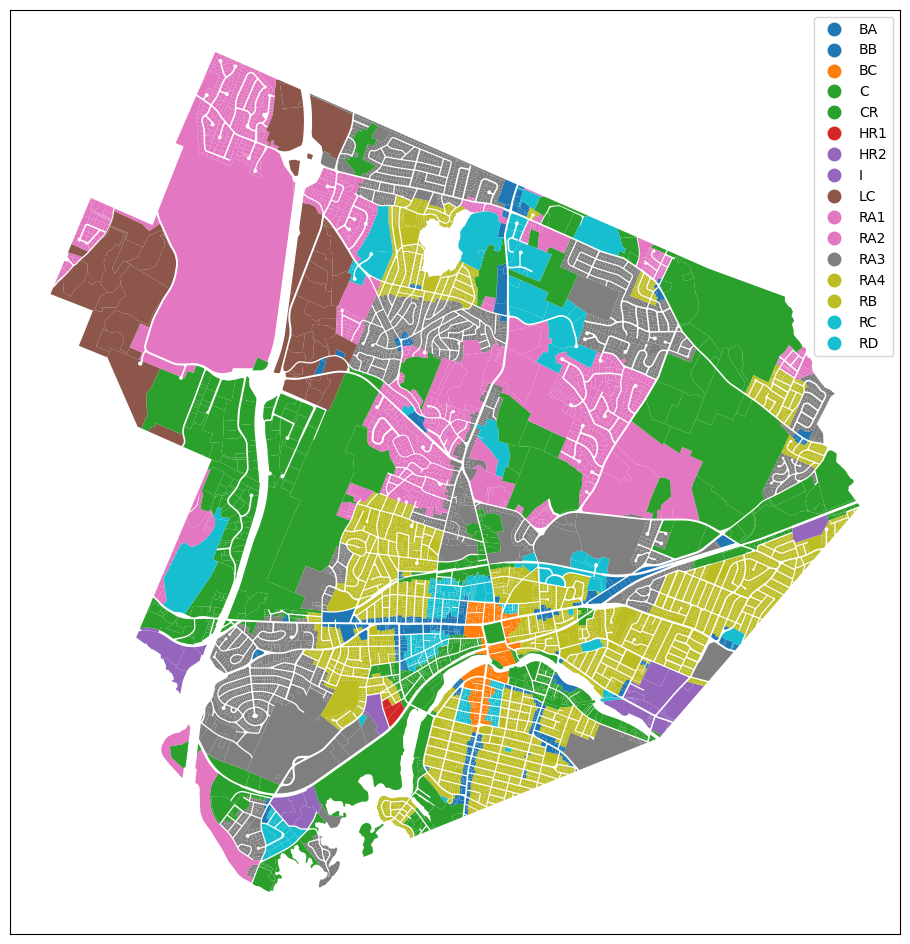

In [12]:
ax = zoned_parcels_df.plot(column="zone", legend=True, figsize=(12, 12))

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

In [13]:
# assign buildings to zones
zoned_buildings_df = buildings_df.sjoin(zoning_df, how="left", predicate="within")
zoned_buildings_df = zoned_buildings_df[["geom", "NAME", BLDG_FOOTPRINT_ACRE]]
zoned_buildings_df.rename(columns={"NAME": "zone"}, inplace=True)
zoned_buildings_df

,geom,zone,BLDG_FOOTPRINT_ACRE
0,"MULTIPOLYGON (((221761.404 902058.868, 221760....",RC,0.051775
1,"MULTIPOLYGON (((220745.377 903053.674, 220730....",RB,0.054356
2,"MULTIPOLYGON (((221283.985 901835.588, 221280....",RB,0.031126
3,"MULTIPOLYGON (((221292.795 905675.213, 221285....",RA3,0.025026
4,"MULTIPOLYGON (((221290.367 905779.246, 221283....",RA3,0.019577
...,...,...,...
16249,"MULTIPOLYGON (((224299.988 903635.333, 224302....",RA4,0.056705
16250,"MULTIPOLYGON (((224623.83 903572.723, 224626.9...",RA4,0.030682
16251,"MULTIPOLYGON (((224622.55 903576.882, 224611.0...",RA4,0.032314
16252,"MULTIPOLYGON (((224655.978 903495.312, 224650....",RA4,0.028626


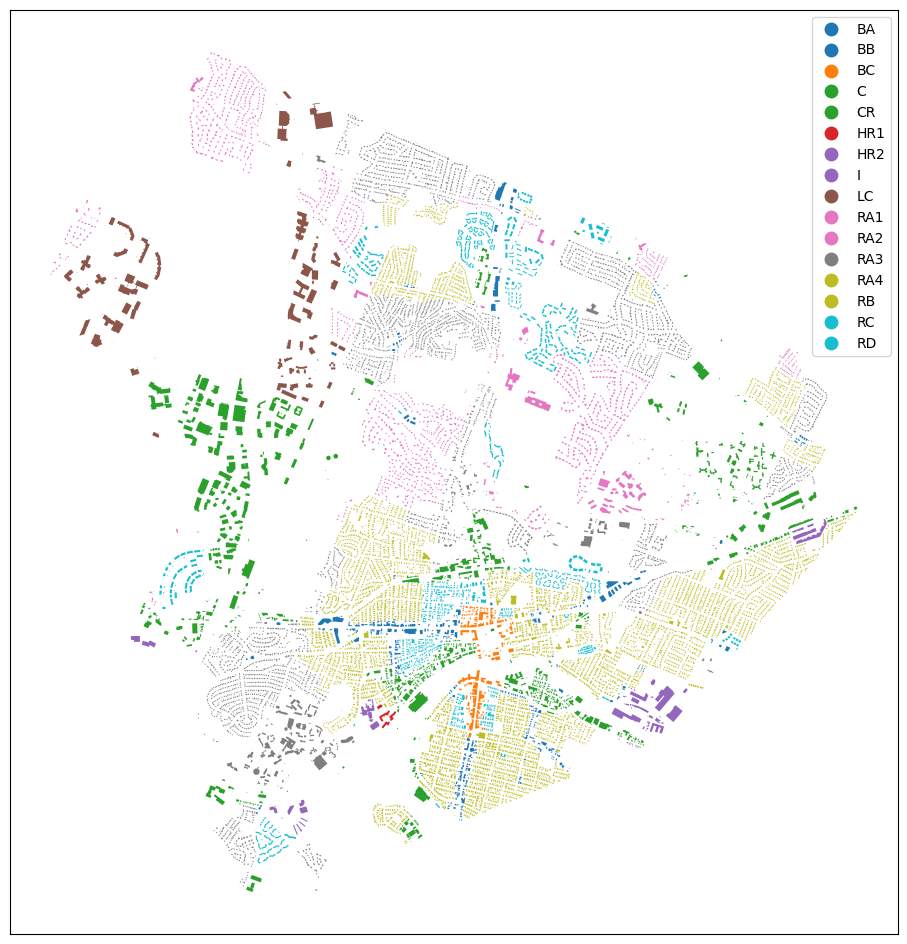

In [14]:
ax = zoned_buildings_df.plot(column="zone", legend=True, aspect=1, figsize=(12, 12))

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

In [15]:
# get the largest building on each parcel
zoned_buildings_df["geom"] = zoned_buildings_df.centroid

principal_bldgs_df = zoned_parcels_df.sjoin(zoned_buildings_df, how="right", predicate="contains")

In [16]:
# we want the largest building on a parcel, so we'll sort by LOC_ID, and then built out area descending
principal_bldgs_df.sort_values(by=["LOC_ID", BLDG_FOOTPRINT_ACRE], ascending=[True, False], inplace=True)
principal_bldgs_df.dropna(subset=["LOC_ID"], inplace=True)
principal_bldgs_df.drop_duplicates(subset=["LOC_ID"], keep="first", inplace=True)

In [17]:
principal_bldgs_df = principal_bldgs_df[["LOC_ID", BLDG_FOOTPRINT_ACRE]]

In [18]:
principal_bldgs_df

,LOC_ID,BLDG_FOOTPRINT_ACRE
1414,F_714281_2972952,0.024312
8838,F_714362_2973054,0.047475
14997,F_714399_2973264,0.064689
12130,F_714449_2973138,0.040028
6134,F_714535_2973230,0.042209
...,...,...
4762,F_738551_2965680,0.028308
11939,F_738563_2965602,0.031165
5632,F_738576_2965643,0.015359
11295,F_738666_2965735,0.029563


In [19]:
zoned_parcels_df = zoned_parcels_df.merge(principal_bldgs_df, on="LOC_ID", how="left")
zoned_parcels_df = zoned_parcels_df.merge(assessments_df, how="inner", on=["LOC_ID"])

# 101 is the single family use code in MassGIS
def get_sfh_mfh_groups(df):
    groups = {
        "single family": df[df["USE_CODE"] == 101],
        "multi family": df[df["USE_CODE"] != 101],
    }

    return groups


In [20]:
zoned_parcels_df.head()

,LOC_ID,geom,zone,PARCEL_AREA_ACRE,BLDG_FOOTPRINT_ACRE,SITE_ADDR,YEAR_BUILT,UNITS,RES_AREA,STORIES,USE_CODE,BLD_AREA,assumed_height
0,F_720118_2954451,"MULTIPOLYGON (((219510.406 900516.563, 219505....",RA3,0.103024,0.017571,759 SOUTH ST,1975,1,1612.0,2,101,1924.0,8.5344
1,F_720144_2954524,"MULTIPOLYGON (((219521.229 900544.743, 219512....",RA3,0.216257,0.047155,753 -55 SOUTH ST,1860,2,5677.0,3,104,7786.0,12.8016
2,F_722474_2954539,"MULTIPOLYGON (((220212.276 900527.633, 220199....",RA3,0.102640,NaN,72 LOT EDGEWATER DR,0,0,0.0,NaN,132,0.0,NaN
3,F_720055_2954540,"MULTIPOLYGON (((219481.807 900560.359, 219483....",RA3,0.265953,0.027685,757 SOUTH ST,1975,1,960.0,1,101,2018.0,4.2672
4,F_720183_2954604,"MULTIPOLYGON (((219530.434 900568.77, 219524.3...",RA3,0.152051,0.019973,749 SOUTH ST,1960,1,1517.0,2,101,2759.0,8.5344


## Non-compliance

Parcels might not comply if they're too small. Structures wouldn't comply based on their shape or closeness to each other. FAR and setback violations turn out to be pretty hard to calculate so we'll skip that for now.

### Parcel size

Some zones have a minimum parcel size requirement.

In [21]:
def parcel_size(row):
    """
    returns True if the
    parcel is too small,
    False if there's no requirement
    or parcel is large enough
    """
    zone = row["zone"]
    min_lot_size = zoning_rules_df.at[zone, "lot area"]

    # no requirement for this parcel or parcel is somehow
    # zero size
    if min_lot_size == float('nan'):
        return False
    elif row[PARCEL_AREA_ACRE] == float('nan') or row[PARCEL_AREA_ACRE] == 0:
        return False
    
    return (row[PARCEL_AREA_ACRE] * SQ_FT_PER_ACRE < min_lot_size)

zoned_parcels_df[PARCEL_SIZE_TOO_SMALL] = zoned_parcels_df.apply(lambda row: parcel_size(row), axis="columns")

In [22]:
zoned_parcels_df[PARCEL_SIZE_TOO_SMALL].value_counts()

parcel_size_too_small
False    7898
True     7252
Name: count, dtype: int64

Text(0.5, 1.0, 'parcel is too small (52.13% in compliance)')

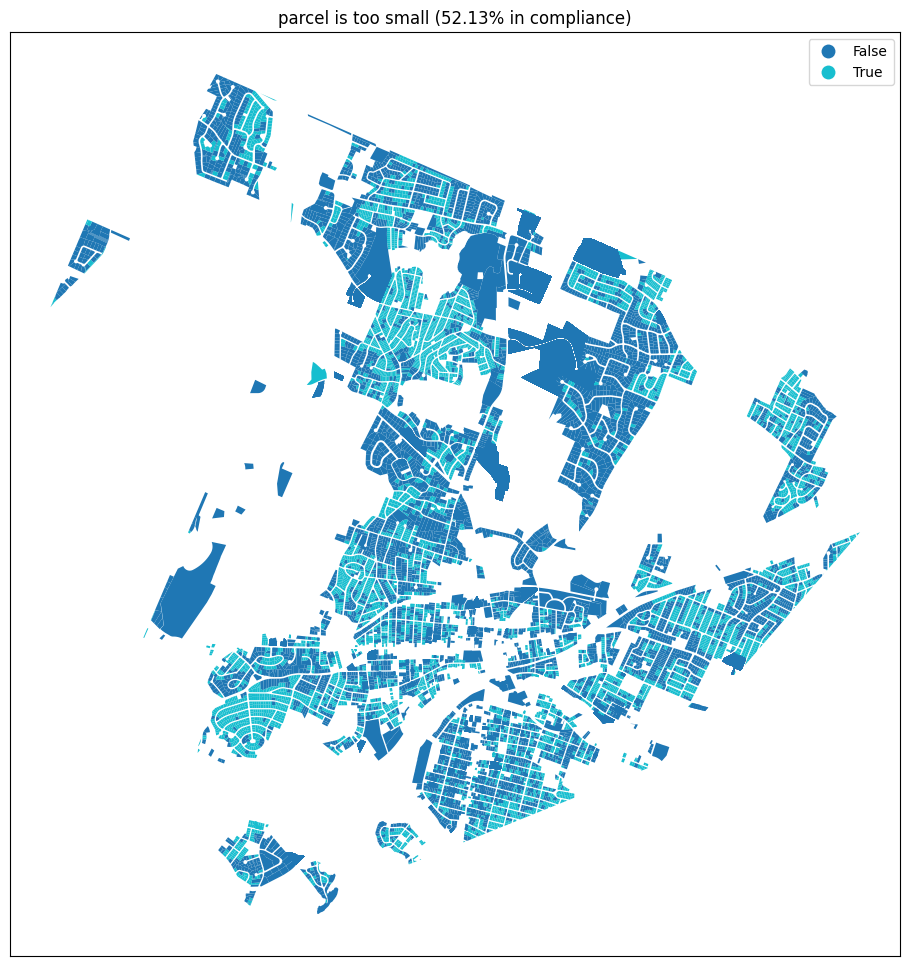

In [23]:
ax = zoned_parcels_df.plot(column=PARCEL_SIZE_TOO_SMALL, legend=True, figsize=(12, 12))

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

pct_in_compliance = 100*len(zoned_parcels_df[~zoned_parcels_df[PARCEL_SIZE_TOO_SMALL]]) / len(zoned_parcels_df)

ax.set_title(f"parcel is too small ({pct_in_compliance:.2f}% in compliance)")

### Impact by housing style

Since this is the single most impactful zoning requirement, how much does it affect our housing stock?

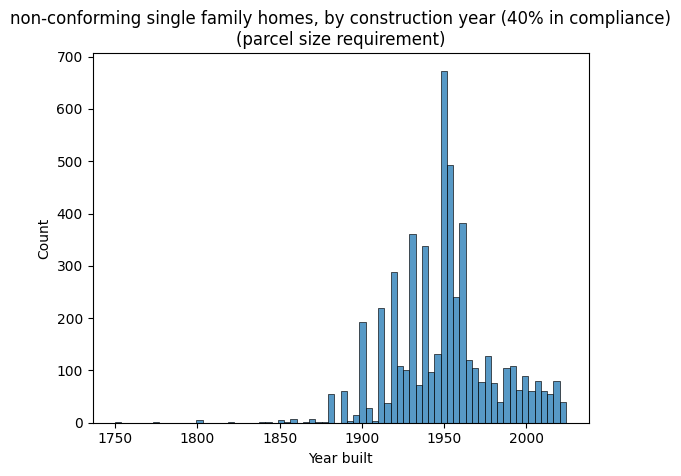

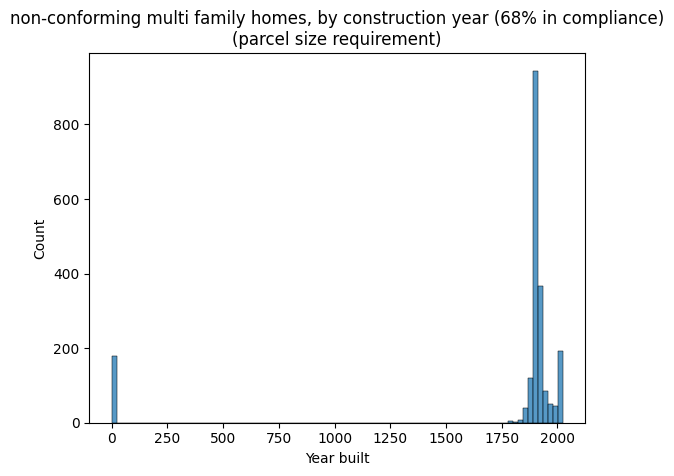

In [24]:

for name, filtered_df in get_sfh_mfh_groups(zoned_parcels_df).items():
    
    plt.figure()

    c = (filtered_df[PARCEL_SIZE_TOO_SMALL])

    ax = sns.histplot(
        filtered_df[c],
        x="YEAR_BUILT"
    )
    ax.set_xlabel("Year built")

    pct_in_compliance = 100 * len(filtered_df[~c]) / len(filtered_df)

    ax.set_title(f"non-conforming {name} homes, by construction year ({pct_in_compliance:0.0f}% in compliance)\n(parcel size requirement)")

### Too many stories

In [25]:
def stories_high(row):
    """
    returns True if the
    structure on the parcel
    has too many stories,
    False if there's no requirement
    """
    zone = row["zone"]
    allowed_stories = zoning_rules_df.at[zone, "stories"]

    # no requirement for this parcel
    if allowed_stories == float('nan') or allowed_stories == "":
        return False
    elif row["STORIES"] == float('nan') or row["STORIES"] == "" or not row["STORIES"]:
        return False

    return (float(row["STORIES"]) > float(allowed_stories))

zoned_parcels_df[STORIES_HIGH] = zoned_parcels_df.apply(lambda row: stories_high(row), axis=1)
zoned_parcels_df[STORIES_HIGH].value_counts()

stories_high
False    14961
True       189
Name: count, dtype: int64

Text(0.5, 1.0, 'built structure has too many stories (98.75% in compliance)')

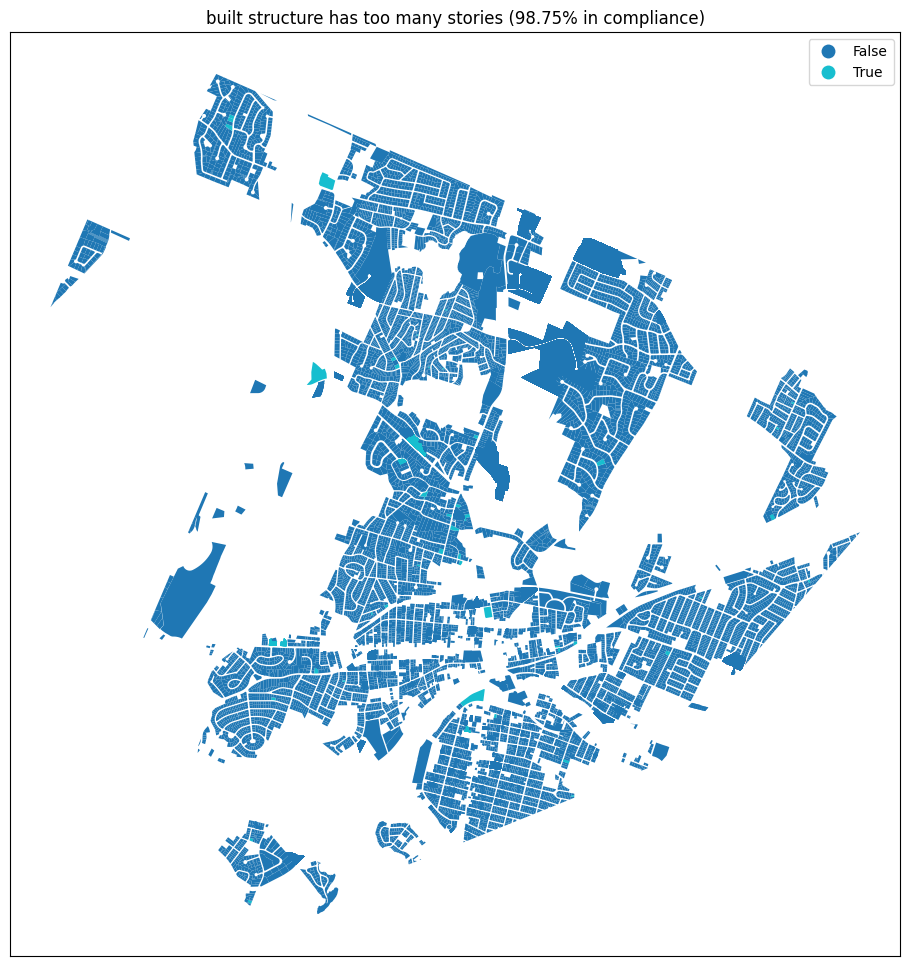

In [26]:
ax = zoned_parcels_df.plot(column=STORIES_HIGH, legend=True, figsize=(12, 12))

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

pct_in_compliance = 100*len(zoned_parcels_df[~zoned_parcels_df[STORIES_HIGH]]) / len(zoned_parcels_df)

ax.set_title(f"built structure has too many stories ({pct_in_compliance:.2f}% in compliance)")

### Dwelling units per acre too high

In [27]:
def too_many_units_per_acre(row):
    """
    returns True for high density,
    or residential structure type is
    forbidden
    """

    zone = row["zone"]
    max_dua = zoning_rules_df.at[zone, "max DUA"]
    as_built_units = row["UNITS"]
    lot_size = row[PARCEL_AREA_ACRE]
    
    # these rules aren't in the table, they're in the text of the code
    if "RA" in zone:
        return as_built_units > 1
    elif "RB" in zone:
        return as_built_units > 2
    elif zone in ["I", "C", "LC"]:
        return as_built_units > 0

    # no requirement for this parcel or parcel is somehow
    # zero size
    if pd.isna(max_dua) or max_dua == "":
        return False
    elif as_built_units == float('nan') or as_built_units == "" or lot_size == 0:
        return False

    return as_built_units / lot_size > max_dua

zoned_parcels_df[TOO_MANY_UNITS_PER_ACRE] = zoned_parcels_df.apply(lambda row: too_many_units_per_acre(row), axis=1)

In [28]:
zoned_parcels_df[TOO_MANY_UNITS_PER_ACRE].value_counts()

too_many_units_per_acre
False    13255
True      1895
Name: count, dtype: int64

Text(0.5, 1.0, 'built structure has too many units (87.49% in compliance)')

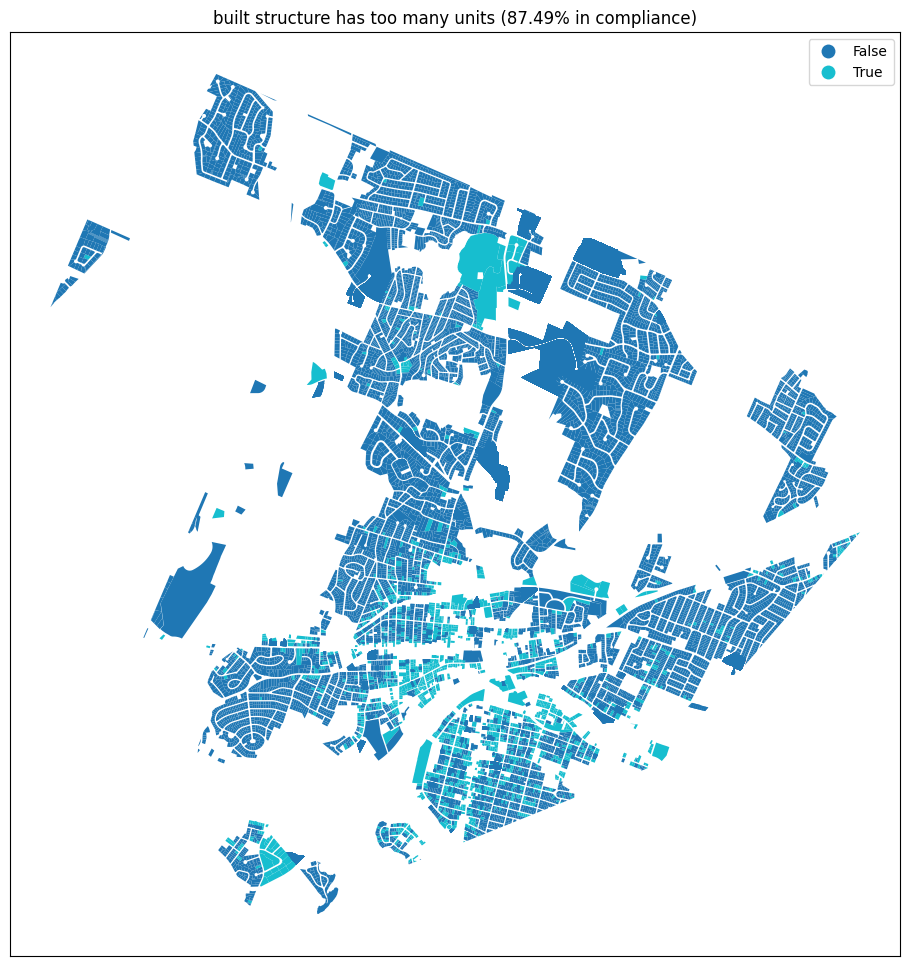

In [29]:
ax = zoned_parcels_df.plot(column=TOO_MANY_UNITS_PER_ACRE, legend=True, figsize=(12, 12))

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

pct_in_compliance = 100*len(zoned_parcels_df[~zoned_parcels_df[TOO_MANY_UNITS_PER_ACRE]]) / len(zoned_parcels_df)

ax.set_title(f"built structure has too many units ({pct_in_compliance:.2f}% in compliance)")

### Max lot coverage violations

In [30]:
def lot_coverage_too_high(row):
    """
    returns True if the lot coverage
    of the built structure is
    higher than allowed
    """


    zone = row["zone"]
    max_lot_coverage = zoning_rules_df.at[zone, "max lot coverage"]
    bld_area = row[BLDG_FOOTPRINT_ACRE]
    lot_size = row[PARCEL_AREA_ACRE]

    if pd.isna(max_lot_coverage) or max_lot_coverage == "":
        return {LOT_COVERAGE_HIGH: False, "coverage": 0.0}
    elif bld_area == float('nan') or bld_area == "":
        return {LOT_COVERAGE_HIGH: False, "coverage": 0.0}

    coverage = bld_area / lot_size
    return { LOT_COVERAGE_HIGH: coverage > max_lot_coverage, "coverage": coverage}

zoned_parcels_df[[LOT_COVERAGE_HIGH, "coverage"]] = zoned_parcels_df.apply(lambda row: lot_coverage_too_high(row), axis="columns", result_type="expand")

In [31]:
zoned_parcels_df[LOT_COVERAGE_HIGH].value_counts()

lot_coverage_too_high
False    12256
True      2894
Name: count, dtype: int64

Text(0.5, 1.0, 'lot coverage too high (80.90% in compliance)')

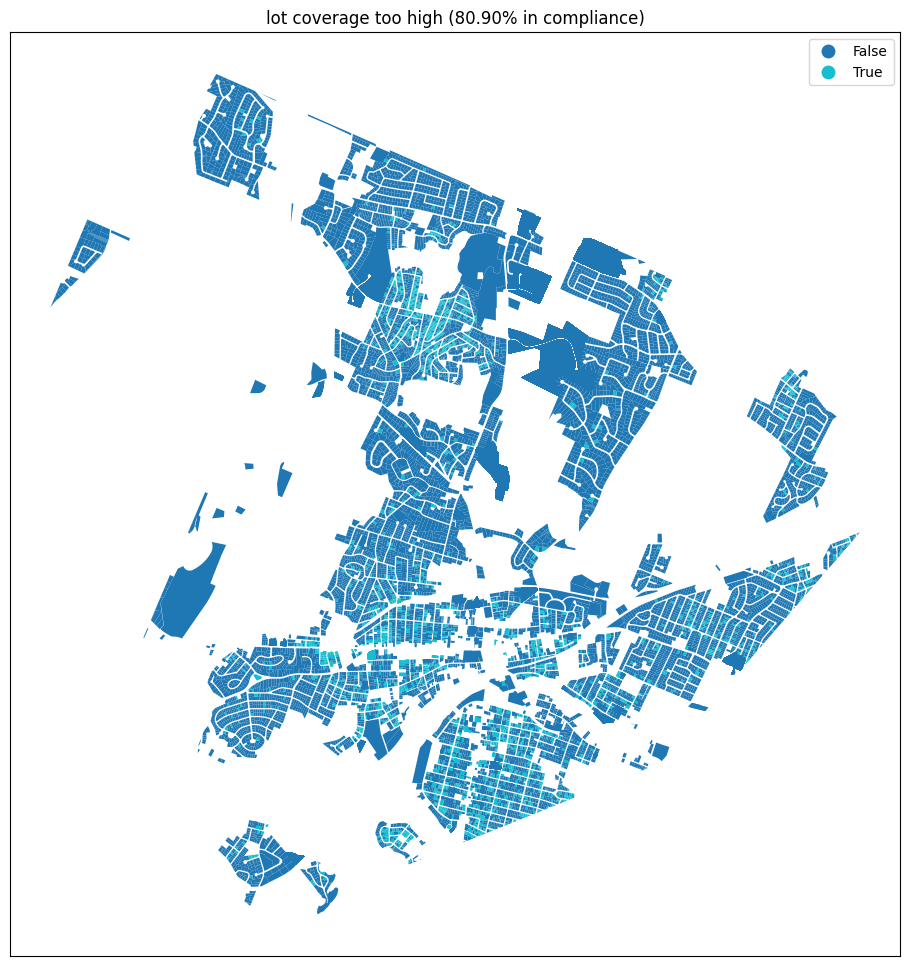

In [32]:
ax = zoned_parcels_df.plot(column=LOT_COVERAGE_HIGH, legend=True, figsize=(12, 12))

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

pct_in_compliance = 100*len(zoned_parcels_df[~zoned_parcels_df[LOT_COVERAGE_HIGH]]) / len(zoned_parcels_df)

ax.set_title(f"lot coverage too high ({pct_in_compliance:.2f}% in compliance)")

### FAR violations

(floor area ratio, another way to discourage massing)

In [33]:
def far_high(row):
    """
    returns True if the lot coverage
    of the built structure is
    higher than allowed
    """

    zone = row["zone"]
    far_limit = zoning_rules_df.at[zone, "FAR by right"]
    bld_area = row[BLDG_FOOTPRINT_ACRE]
    STORIES = row["STORIES"]
    lot_size = row[PARCEL_AREA_ACRE]

    if pd.isna(far_limit) or far_limit in["", 0] or lot_size == 0:
        return {FAR_HIGH: False, "far": 0.0}
    elif bld_area in [float('nan'), ""] or STORIES in [float('nan'), "", None]:
        return {FAR_HIGH: False, "far": 0.0}

    # assumes a perfectly extruded structure
    far = (bld_area * float(STORIES) / lot_size)
    
    return {FAR_HIGH: far > far_limit, "far": far}

zoned_parcels_df[[FAR_HIGH, "far"]] = zoned_parcels_df.apply(lambda row: far_high(row), axis='columns', result_type='expand')

In [34]:
zoned_parcels_df[FAR_HIGH].value_counts()

far_high
False    13653
True      1497
Name: count, dtype: int64

Text(0.5, 1.0, 'FAR too high (90.12% in compliance)')

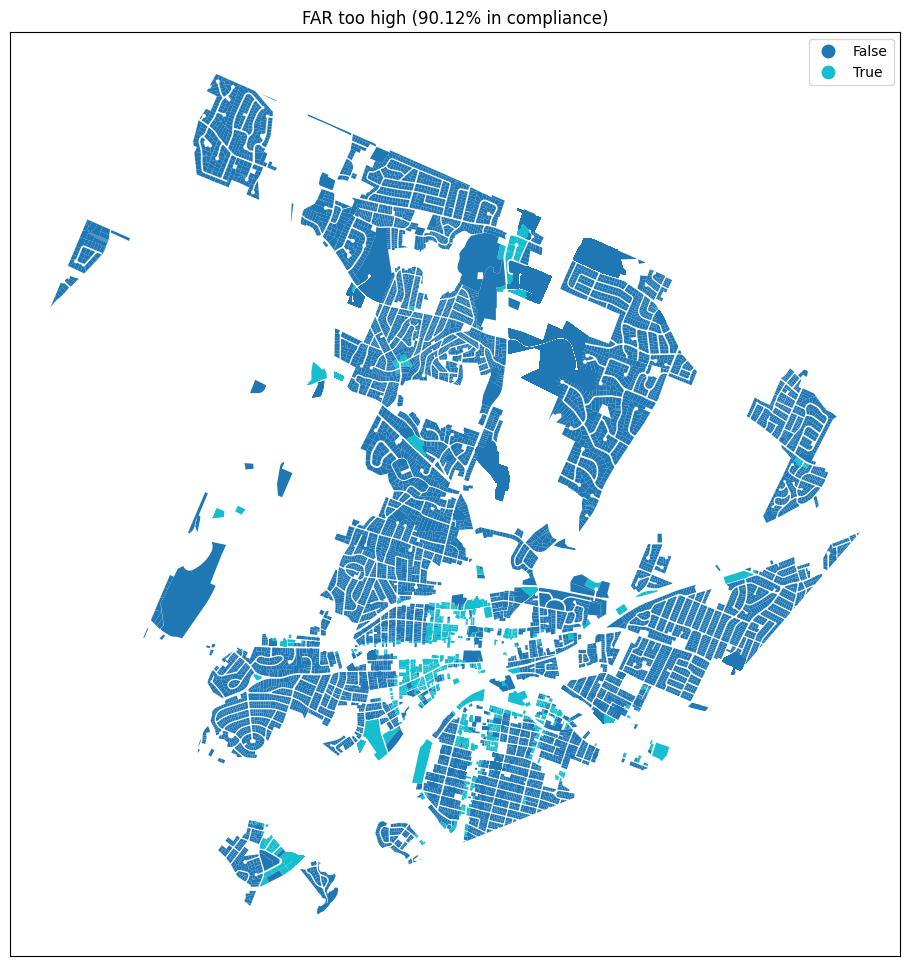

In [35]:
ax = zoned_parcels_df.plot(column=FAR_HIGH, legend=True, figsize=(12, 12))

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

pct_in_compliance = 100*len(zoned_parcels_df[~zoned_parcels_df[FAR_HIGH]]) / len(zoned_parcels_df)

ax.set_title(f"FAR too high ({pct_in_compliance:.2f}% in compliance)")

## All parcels that are illegal

(for any combination of zoning violations)

In [36]:
def any_violations(row):
    
    return row[PARCEL_SIZE_TOO_SMALL] or row[STORIES_HIGH] or row[TOO_MANY_UNITS_PER_ACRE] or row[FAR_HIGH] or row[LOT_COVERAGE_HIGH]

zoned_parcels_df[ANY_VIOLATIONS] = zoned_parcels_df.apply(lambda row: any_violations(row), axis=1, result_type='expand')

In [37]:
zoned_parcels_df[ANY_VIOLATIONS].value_counts()

any_violations
True     9209
False    5941
Name: count, dtype: int64

Text(0.5, 1.0, 'parcels with at least one violation (39.21% in compliance)')

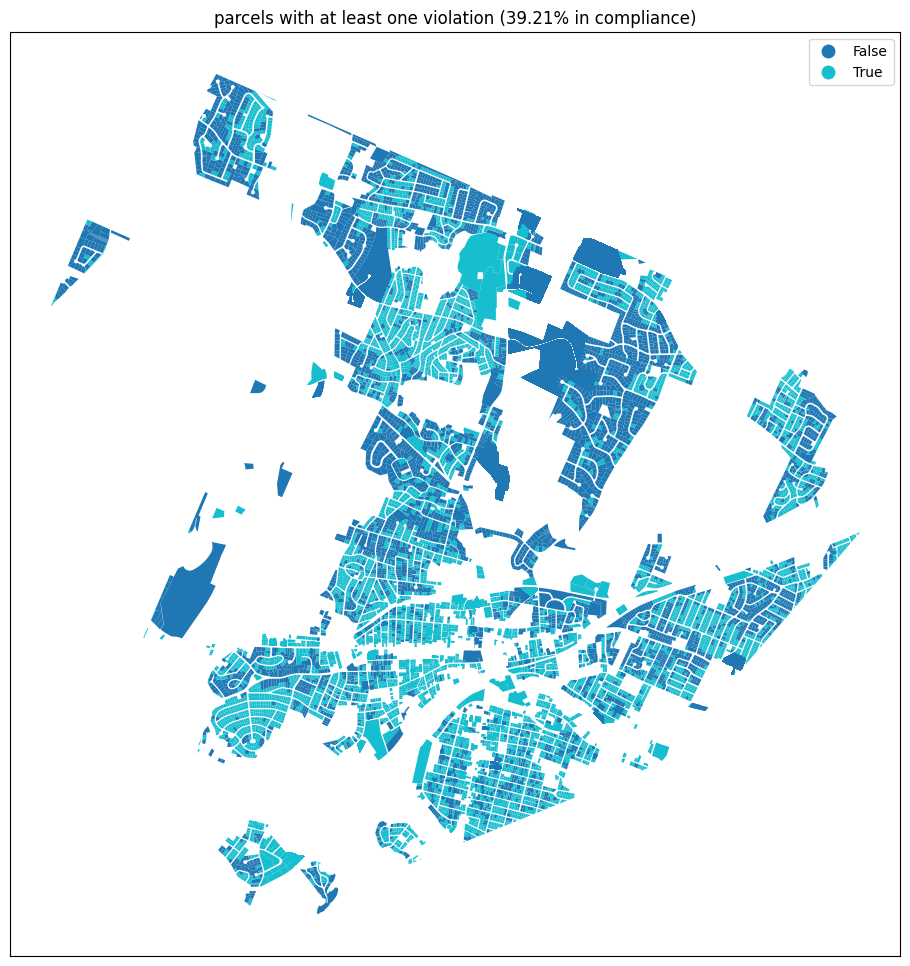

In [38]:
ax = zoned_parcels_df.plot(column=ANY_VIOLATIONS, legend=True, figsize=(12, 12))

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

pct_in_compliance = 100*len(zoned_parcels_df[~zoned_parcels_df[ANY_VIOLATIONS]]) / len(zoned_parcels_df)

ax.set_title(f"parcels with at least one violation ({pct_in_compliance:.2f}% in compliance)")


### The greatest scofflaws

Most non-conforming parcels in the city

In [39]:
def num_violations(row):
    
    return row[PARCEL_SIZE_TOO_SMALL] + row[STORIES_HIGH] + row[TOO_MANY_UNITS_PER_ACRE] + row[FAR_HIGH] + row[LOT_COVERAGE_HIGH]

zoned_parcels_df["num_violations"] = zoned_parcels_df.apply(lambda row: num_violations(row), axis=1, result_type='expand')

In [40]:
zoned_parcels_df["num_violations"].value_counts()

num_violations
0    5941
1    5819
2    2484
3     684
4     222
Name: count, dtype: int64

Text(0.5, 1.0, 'number of violations per parcel')

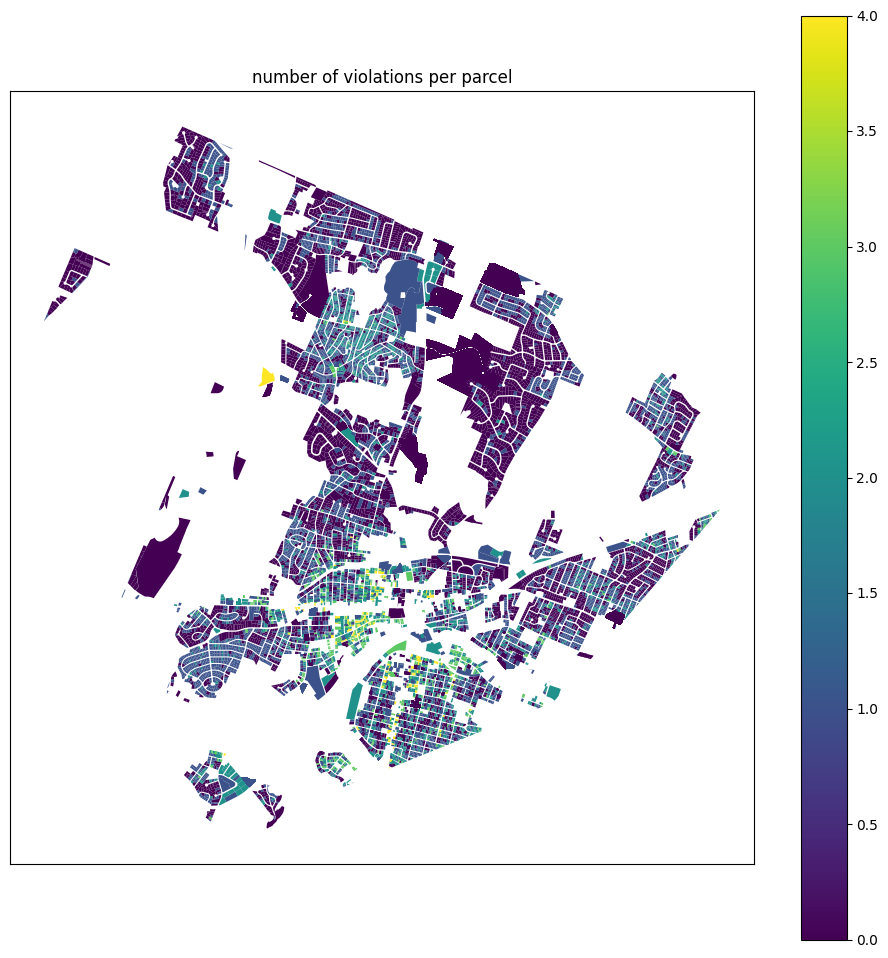

In [41]:
ax = zoned_parcels_df.plot(column="num_violations", legend=True, figsize=(12, 12))

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

ax.set_title(f"number of violations per parcel")

#### Violations by year built

What is the real character of the city? The older structures, or the newer ones?
Of course you would expect that newer structures would be more likely to be acceptable (since that was the whole point of the zoning),
but if you didn't have any bias against the older stock, you would have incorporated into the zoning code.

Text(0.5, 1.0, 'parcels with at least one violation, by construction year (39.21% in compliance)')

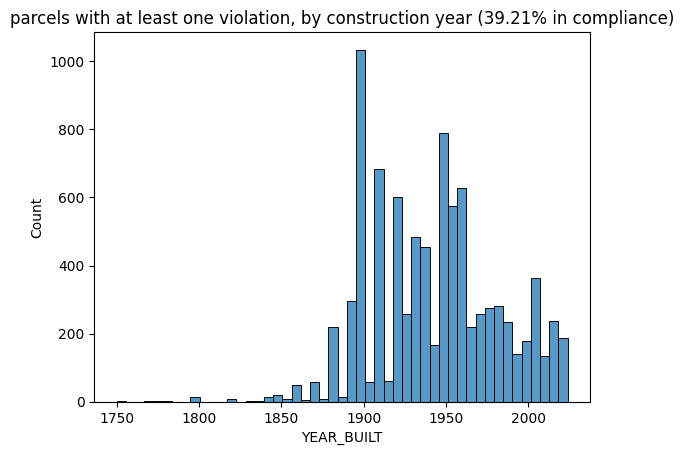

In [42]:
ax = sns.histplot(
    zoned_parcels_df[
        (zoned_parcels_df["YEAR_BUILT"] > 1740) & (zoned_parcels_df[ANY_VIOLATIONS])
    ], 
    x="YEAR_BUILT"
)

pct_in_compliance = 100 * len(zoned_parcels_df[~zoned_parcels_df[ANY_VIOLATIONS]]) / len(zoned_parcels_df)

ax.set_title(f"parcels with at least one violation, by construction year ({pct_in_compliance:.2f}% in compliance)")

... but if you were really caring about preserving the character of the city, why are there so many structures built before 1960 (and more than half of them!) not in compliance?

**Do we value the already built up environment, or not?**

#### Violations weighted by units built (i.e. units in parcels that have residential uses)

Some people live in SFH, but Waltham is 50% renters, so many of us live in MFH housing. Are most of us living in a non-conforming home?

In [43]:
# collect a record for each unit (there's probably a more efficient way to do this)

df = (
    zoned_parcels_df[["YEAR_BUILT", ANY_VIOLATIONS]]
    .loc[zoned_parcels_df.index.repeat(zoned_parcels_df["UNITS"])]
    .reset_index(drop=True)
)

df

,YEAR_BUILT,any_violations
0,1975,True
1,1860,True
2,1860,True
3,1975,False
4,1960,True
...,...,...
24383,2023,True
24384,2023,True
24385,2024,False
24386,2024,False


Text(0.5, 1.0, 'units in parcels with violations, by construction year (27% in compliance)')

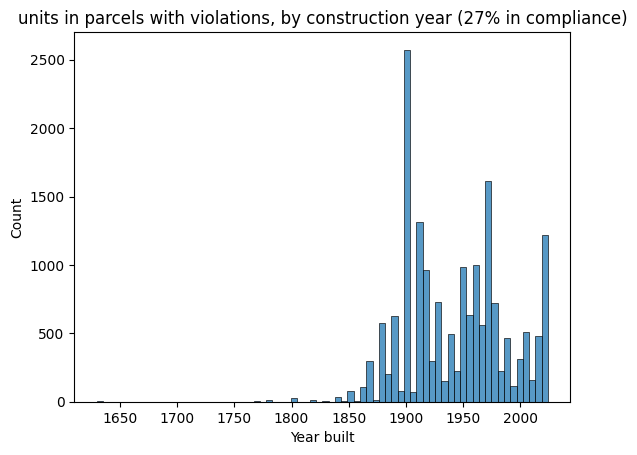

In [44]:
ax = sns.histplot(
    df[df[ANY_VIOLATIONS]], 
    x="YEAR_BUILT"
)
ax.set_xlabel("Year built")

pct_in_compliance = 100 * len(df[~df[ANY_VIOLATIONS]]) / len(df)

ax.set_title(f"units in parcels with violations, by construction year ({pct_in_compliance:0.0f}% in compliance)")

It seems quite plausible that most of us are living in non-conforming dwellings (one would need per-unit population to be sure).

#### Violations by structure type

Did the zoning even do a good job of protecting the character of existing single family homes?

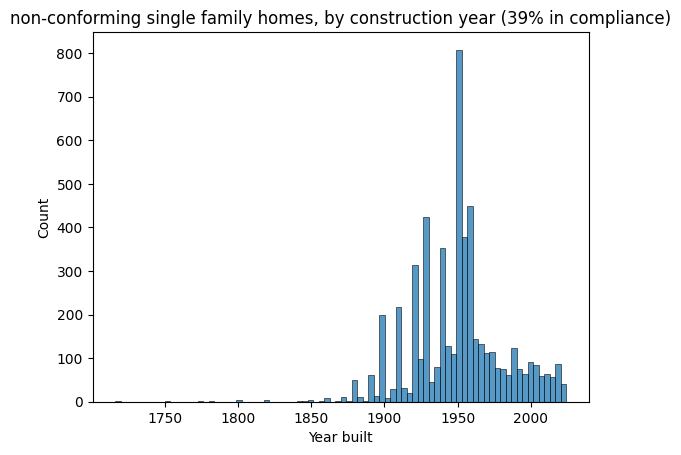

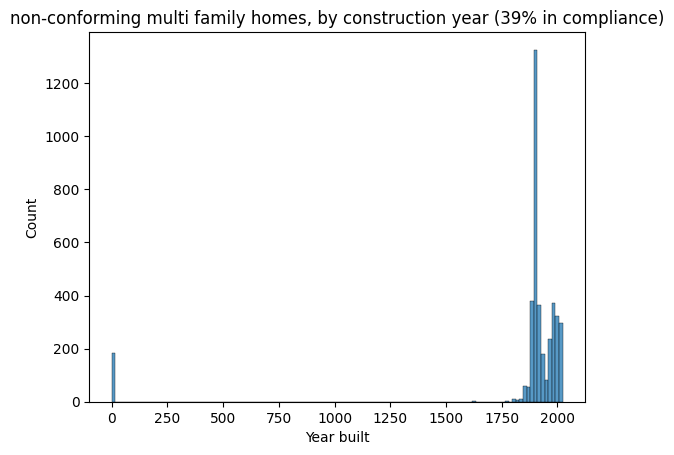

In [45]:

for name, filtered_df in get_sfh_mfh_groups(zoned_parcels_df).items():
    
    plt.figure()

    c = (filtered_df[ANY_VIOLATIONS])

    ax = sns.histplot(
        filtered_df[c],
        x="YEAR_BUILT"
    )
    ax.set_xlabel("Year built")

    pct_in_compliance = 100 * len(filtered_df[~c]) / len(filtered_df)

    ax.set_title(f"non-conforming {name} homes, by construction year ({pct_in_compliance:0.0f}% in compliance)")

I'm not sure what happened with 1950's single family homes, but I guess we really don't want them around anymore. We built a bunch and then a few decades later, decided to apply rules so we can't build like that anymore.

Ironically, we actually do a (very slightly) better job of compliance with multi-family housing, but probably only because we banned them very early.

# The chilling effect on development

What happened to the rate of construction of housing units over time? What does this situation look like for MFH vs. SFH? By single structure, and by unit?

Text(0.5, 0, 'year built')

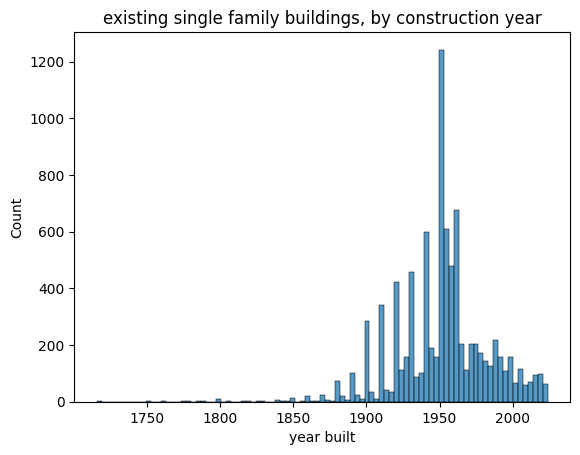

In [46]:
temp_df = assessments_df[assessments_df["USE_CODE"] == 101]    

ax = sns.histplot(
        temp_df,
        x="YEAR_BUILT"
)
ax.set_title(f"existing single family buildings, by construction year")
ax.set_xlabel("year built")

Text(0.5, 0, 'year built')

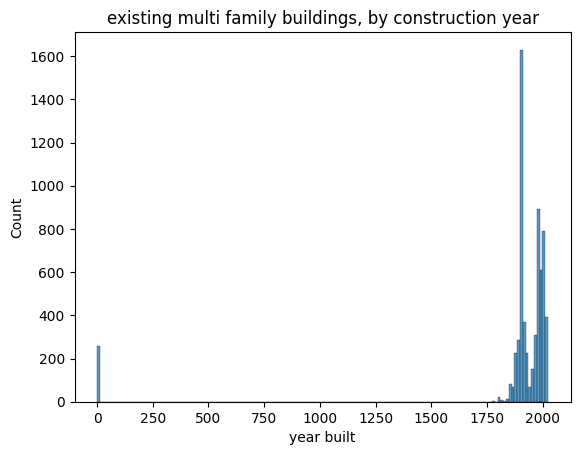

In [47]:
temp_df = assessments_df[(assessments_df["USE_CODE"] < 200) & (assessments_df["USE_CODE"] != 101)]  

ax = sns.histplot(
        temp_df,
        x="YEAR_BUILT"
)
ax.set_title(f"existing multi family buildings, by construction year")
ax.set_xlabel("year built")

Text(0.5, 0, 'year built')

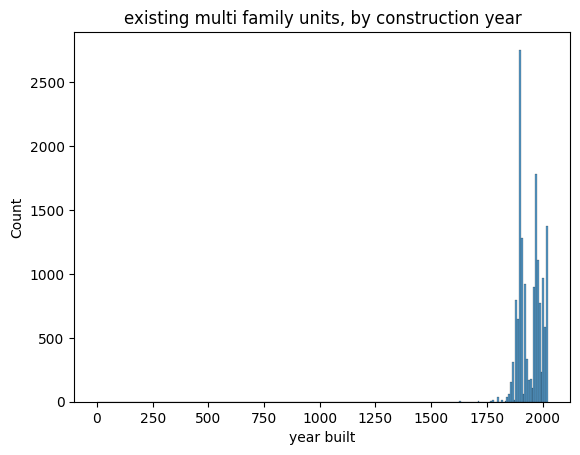

In [48]:
temp_df = assessments_df[(assessments_df["USE_CODE"] < 200) & (assessments_df["USE_CODE"] != 101)]
temp_df = temp_df[["YEAR_BUILT"]].loc[temp_df.index.repeat(temp_df["UNITS"])].reset_index(drop=True)

ax = sns.histplot(
        temp_df,
        x="YEAR_BUILT"
)
ax.set_title(f"existing multi family units, by construction year")
ax.set_xlabel("year built")

## Upload data

This isn't part of the analysis, I'm just saving the data to my database and generating an offline map.

In [49]:
zoned_parcels_df.to_postgis("illegal_zoning", con, if_exists="replace")

In [53]:
# prepare for mapping by converting to a lat/lon CRS
zoned_parcels_df.to_crs("EPSG:4326", inplace=True)

# the HTML map generates some odd shading artifacts because we have multiple properties
# under the same LOC_ID -> dedup them with this aggregation,
# and keep only the columns we need from here
map_df = zoned_parcels_df.groupby("LOC_ID", as_index=False).agg(
    geom=("geom", "first"),
    SITE_ADDR=("SITE_ADDR", "first"),
    **{LOT_COVERAGE_HIGH: (LOT_COVERAGE_HIGH, "any")},
    **{STORIES_HIGH: (STORIES_HIGH, "any")},
    **{TOO_MANY_UNITS_PER_ACRE: (TOO_MANY_UNITS_PER_ACRE, "any")},
    **{PARCEL_SIZE_TOO_SMALL: (PARCEL_SIZE_TOO_SMALL, "any")},
    **{ANY_VIOLATIONS: (ANY_VIOLATIONS, "any")},
    **{FAR_HIGH: (FAR_HIGH, "any")},
    far=("far", "max"),
    coverage=("coverage", "max"),
)
map_df = geo_pd.GeoDataFrame(map_df, geometry="geom", crs=zoned_parcels_df.crs)

In [54]:
center = [42.3, -71.2]
bounds = map_df.total_bounds.tolist()
m = folium.Map(
    location=center,
    zoom_start=10,
    tiles="cartodbpositron",
    max_bounds=True,
    min_lat=bounds[1] - 0.01,
    max_lat=bounds[3] + 0.01,
    min_lon=bounds[0] - 0.01,
    max_lon=bounds[2] + 0.01,
    max_width=800,
    prefer_canvas=True
)

m.fit_bounds([bounds[:2][::-1], bounds[2:][::-1]])

tooltip = folium.GeoJsonTooltip(
    fields=[
        "SITE_ADDR",
        PARCEL_SIZE_TOO_SMALL,
        STORIES_HIGH,
        TOO_MANY_UNITS_PER_ACRE,
        LOT_COVERAGE_HIGH,
        "coverage",
        FAR_HIGH,
        "far"
    ],
    aliases=[
        "Address",
        "Parcel is too small",
        "Too many stories",
        "Too many units on parcel",
        "Lot coverage too high",
        "coverage",
        "FAR too high",
        "far"
    ],
    localize=True,
    sticky=False,
    labels=True,
    style="""
        background-color: #F0EFEF;
        border: 2px solid black;
        border-radius: 3px;
        box-shadow: 3px;
    """,
    min_zoom=2,
)

def fill_rule(feature):
    return {
        "fillColor": "red" if feature["properties"][ANY_VIOLATIONS] == 1 else "green",
        "color": "black",
        "weight": 1,
        "fillOpacity": 0.2,
    }


parcels_geo = folium.GeoJson(
    map_df, style_function=lambda feature: fill_rule(feature), tooltip=tooltip
)
parcels_geo.add_to(m)

StreetViewPanel(parcels_geo.get_name()).add_to(m)

addr_search = Search(
    layer=parcels_geo,
    geom_type="Polygon",
    placeholder="Search by address",
    collapsed=False,
    search_label="SITE_ADDR",
    weight=3,
).add_to(m)

In [55]:

# uncomment to show - usually makes the file too big to show in github though
# m

In [56]:
os.makedirs("published", exist_ok=True)
m.save("published/illegal_zoning.html", bounds=(bounds[:2][::-1] + bounds[2:][::-1]), maxBoundsViscosity=1.0)

In [57]:
# Inject URL hash sync script into the saved HTML so the map state is shareable via link
# Format: #map=lat/lng/zoom
import re

html_path = "published/illegal_zoning.html"
with open(html_path, "r", encoding="utf-8") as f:
    html = f.read()

# Find the folium-generated map variable name (e.g. map_20bde40a7327406a164b537a702520dd)
map_var = re.search(r'var (map_[0-9a-f]+) = L\.map\(', html).group(1)

url_sync_script = f"""
    <script>
        window.addEventListener(\"load\", function () {{
            var map = {map_var};

            // Always update URL hash on map movement
            map.on(\"moveend\", function () {{
                var center = map.getCenter();
                var zoom = map.getZoom();
                history.replaceState(null, \"\", \"#map=\" + center.lat.toFixed(5) + \"/\" + center.lng.toFixed(5) + \"/\" + zoom);
            }});

            // Restore view from URL hash after initial fitBounds animation settles
            var hash = window.location.hash;
            if (!hash || !hash.startsWith(\"#map=\")) return;

            var parts = hash.slice(5).split(\"/\");
            if (parts.length !== 3) return;

            var lat = parseFloat(parts[0]);
            var lng = parseFloat(parts[1]);
            var zoom = parseInt(parts[2]);
            if (isNaN(lat) || isNaN(lng) || isNaN(zoom)) return;

            map.once(\"moveend\", function () {{
                map.setView([lat, lng], zoom, {{animate: false}});
            }});
        }});
    </script>
"""

html = html.replace("</body>", url_sync_script + "</body>", 1)

with open(html_path, "w", encoding="utf-8") as f:
    f.write(html)
